In [42]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [43]:
ds = sns.load_dataset('titanic')
ds

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [45]:
orginal_data = ds['age'].copy() 

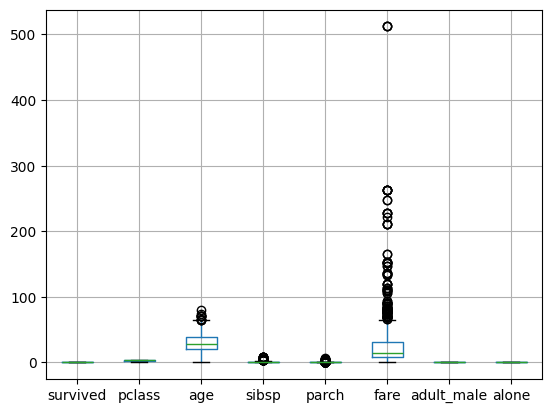

In [46]:
ds.boxplot()
plt.show()

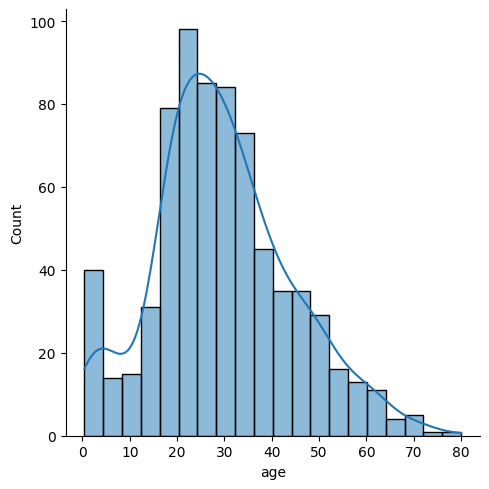

In [47]:
sns.displot(ds['age'] , kde = True)
plt.show()

In [25]:
# there are 2 ways to handel the outliear that was the trimming and capping 

# trimming 

In [48]:
ds['age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

In [49]:
print(f'highest limit {ds['age'].mean() + 3*ds['age'].std()}')
print(f'lowest limit {ds['age'].mean() - 3*ds['age'].std()}')

highest limit 73.27860964406095
lowest limit -13.88037434994331


In [50]:
# detect the outliear 
ds[(ds['age'] > 73.27) | (ds['age'] < -13.80)]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
630,1,1,male,80.0,0,0,30.000,S,First,man,True,A,Southampton,yes,True
851,0,3,male,74.0,0,0,7.775,S,Third,man,True,NaN,Southampton,no,True


In [39]:
# 1st apporach 

In [51]:
new_ds = ds[(ds['age'] <= 73.27) & (ds['age'] >= -13.80)]
new_ds

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


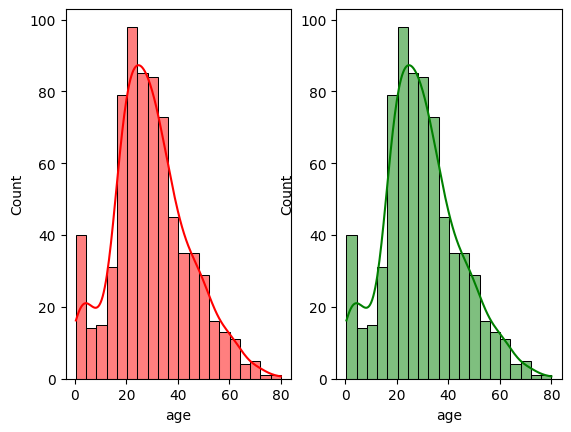

In [54]:
plt.subplot(1,2,1)
sns.histplot(orginal_data, kde = True, color = 'red')

plt.subplot(1,2,2)
sns.histplot(ds['age'], kde = True , color = 'green')
plt.show()

# secand apporach 

In [56]:
ds['age z_score'] = (ds['age'] + ds['age'].mean()) / ds['age'].std()

In [62]:
ds.head()
ds.shape

(891, 16)

# detect the outliear 

In [64]:
ds[(ds['age z_score'] > 3) | (ds['age z_score'] < -3)]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age z_score
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,3.558953
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,4.660388
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,3.834312
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,4.453869
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,4.453869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False,4.729228
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,3.903151
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,3.352434
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,3.834312


# trimming the outliear 

In [65]:
ds[(ds['age z_score'] < 3) & (ds['age z_score'] > -3)]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age z_score
7,0,3,male,2.00,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False,2.182158
10,1,3,female,4.00,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False,2.319838
16,0,3,male,2.00,4,1,29.1250,Q,Third,child,False,NaN,Queenstown,no,False,2.182158
24,0,3,female,8.00,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False,2.595197
43,1,2,female,3.00,1,2,41.5792,C,Second,child,False,NaN,Cherbourg,yes,False,2.250998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
827,1,2,male,1.00,0,2,37.0042,C,Second,child,False,NaN,Cherbourg,yes,False,2.113319
831,1,2,male,0.83,1,1,18.7500,S,Second,child,False,NaN,Southampton,yes,False,2.101616
850,0,3,male,4.00,4,2,31.2750,S,Third,child,False,NaN,Southampton,no,False,2.319838
852,0,3,female,9.00,1,1,15.2458,C,Third,child,False,NaN,Cherbourg,no,False,2.664036


# capping 

In [68]:
upper_limit = ds['age'].mean() + 3*ds['age'].std()
lower_limit = ds['age'].mean() - 3*ds['age'].std()
print(upper_limit)
print(lower_limit)

73.27860964406095
-13.88037434994331


In [70]:
ds['age'] = np.where(ds['age'] > upper_limit, upper_limit,
         np.where(ds['age'] < lower_limit, lower_limit
                  ,ds['age'] 
                 )
        )

In [72]:
ds.shape

(891, 16)

In [73]:
ds['age'].describe()

count    714.000000
mean      29.688694
std       14.492933
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       73.278610
Name: age, dtype: float64